In [3]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.9 MB/s eta 0:00:00


In [80]:
pip install optuna-integration[tfkeras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 4.4 MB/s eta 0:00:00


In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import StandardScaler,MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.regularizers import l1_l2,l2
from keras.optimizers import Adam, RMSprop, SGD, AdamW, Nadam
from keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
import optuna
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, auc

In [85]:
from keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

In [81]:
from optuna.integration import TFKerasPruningCallback

/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.tfkeras` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.tfkeras` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


In [86]:
from keras.callbacks import ReduceLROnPlateau

In [89]:
from keras.callbacks import TerminateOnNaN

In [23]:
df = pd.read_csv("Employee Attrition.csv")

In [24]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,No,11,Bachelor’s Degree,Married,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,No,27,High School,Single,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,Yes,71,High School,Divorced,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.isna().sum()

,0
Employee ID,0
Age,0
Gender,0
Years at Company,0
Job Role,0
Monthly Income,0
Work-Life Balance,0
Job Satisfaction,0
Performance Rating,0
Number of Promotions,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [28]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

In [29]:
df.head(1)

,employee_id,age,gender,years_at_company,job_role,monthly_income,work_life_balance,job_satisfaction,performance_rating,number_of_promotions,overtime,distance_from_home,education_level,marital_status,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed


In [30]:
# Drop unnecessary columns
X = df.drop(columns=["employee_id", "attrition"])
y = df["attrition"]

In [31]:
num_features = X.select_dtypes(include="number").columns.tolist()

print(num_features)

['age', 'years_at_company', 'monthly_income', 'number_of_promotions', 'distance_from_home', 'number_of_dependents', 'company_tenure']


In [32]:
cat_features = X.select_dtypes(include="object").columns.tolist()

print(cat_features)

['gender', 'job_role', 'work_life_balance', 'job_satisfaction', 'performance_rating', 'overtime', 'education_level', 'marital_status', 'job_level', 'company_size', 'remote_work', 'leadership_opportunities', 'innovation_opportunities', 'company_reputation', 'employee_recognition']


In [36]:
y.value_counts()

,count
attrition,
Stayed,31260
Left,28338


In [38]:
y = y.map({"Stayed": 0, "Left": 1})

In [40]:
y.head()

,attrition
0,0
1,0
2,0
3,0
4,0


In [41]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify = y)

In [42]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42,stratify = y_train_full)

In [43]:
num_cols = X.select_dtypes(exclude = "object").columns
cat_cols = X.select_dtypes(include = "object").columns

In [44]:
binary_features = [
    col for col in cat_cols
    if X[col].nunique() == 2
]

binary_features

['gender',
 'overtime',
 'remote_work',
 'leadership_opportunities',
 'innovation_opportunities']

In [57]:
df["employee_recognition"].unique()

array(['Medium', 'Low', 'High', 'Very High'], dtype=object)

In [58]:
ordinal_features = [
    "work_life_balance",
    "job_satisfaction",
    "performance_rating",
    "education_level",
    "job_level",
    "company_reputation",
    "employee_recognition"
]

work_life_balance = ["Poor", "Fair", "Good", "Excellent"]     # Work-Life Balance
job_satisfaction = ["Low", "Medium", "High", "Very High"]     # Job Satisfaction
performance_rating = ["Low", "Below Average", "Average", "High"]                 # Performance Rating
education_level = ["High School", "Associate Degree", "Bachelor’s Degree", "Master’s Degree", "PhD"]
job_level = ["Entry", "Mid", "Senior"]                           # job_level
company_reputation = ["Poor", "Fair", "Good", "Excellent"]     # Company Reputation
employee_recognition = ["Low", "Medium", "High", "Very High"]      # Employee Recognition

In [59]:
nominal_features = [
    col for col in cat_features
    if col not in binary_features + ordinal_features
]

nominal_features

['job_role', 'marital_status', 'company_size']

In [64]:
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                        ('scaler', StandardScaler())])


ordinal_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                             ('encoder',OrdinalEncoder(categories=[work_life_balance,job_satisfaction,performance_rating,education_level,
                                                                    job_level,company_reputation,employee_recognition]))])

nominal_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                             ('encoder',OneHotEncoder(handle_unknown='ignore',drop='first'))])

In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),

        ("binary",
         nominal_pipeline,
         binary_features),

        ("ordinal",
         ordinal_pipeline,
         ordinal_features),

        ("nominal",
         nominal_pipeline,
         nominal_features)
    ],
    remainder='drop' # Default behavior: drops unmentioned columns
)

In [68]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'years_at_company', 'monthly_income', 'number_of_promotions',
       'distance_from_home', 'number_of_dependents', 'company_tenure'],
      dtype='object')),
                                ('binary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_fre...
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['work_life_balance', 'job_satisfaction',
                                  'performance_rating', 'education_level',
                                  'job_level', 'company_reputation',
                                  'employee_recognition']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['job_role', 'marital_status',
                                  'company_size'])])

In [69]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_val_prepared = preprocessor.transform(X_val)
X_test_prepared = preprocessor.transform(X_test)

In [70]:
model = Sequential([Input(shape=(X_train_prepared.shape[1],)),
                    Dense(64,activation="relu"),
                    Dense(32,activation="relu"),
                    Dense(1,activation="sigmoid")])

In [71]:
model.compile(optimizer="Adam",loss = "binary_crossentropy",metrics = ["accuracy"])

In [72]:
early = EarlyStopping(monitor = "val_loss",patience = 5 , restore_best_weights=True)

In [73]:
model.fit(X_train_prepared,y_train,
          epochs = 50,
          validation_data=(X_val_prepared,y_val),
          batch_size=32,
          callbacks=[early],
          verbose = 2)

Epoch 1/50
1192/1192 - 8s - 7ms/step - accuracy: 0.7243 - loss: 0.5296 - val_accuracy: 0.7434 - val_loss: 0.5020
Epoch 2/50
1192/1192 - 3s - 3ms/step - accuracy: 0.7420 - loss: 0.5019 - val_accuracy: 0.7450 - val_loss: 0.5049
Epoch 3/50
1192/1192 - 4s - 3ms/step - accuracy: 0.7448 - loss: 0.4961 - val_accuracy: 0.7450 - val_loss: 0.4995
Epoch 4/50
1192/1192 - 3s - 3ms/step - accuracy: 0.7491 - loss: 0.4916 - val_accuracy: 0.7536 - val_loss: 0.4945
Epoch 5/50
1192/1192 - 3s - 3ms/step - accuracy: 0.7508 - loss: 0.4884 - val_accuracy: 0.7519 - val_loss: 0.4909
Epoch 6/50
1192/1192 - 4s - 3ms/step - accuracy: 0.7515 - loss: 0.4859 - val_accuracy: 0.7516 - val_loss: 0.4899
Epoch 7/50
1192/1192 - 4s - 3ms/step - accuracy: 0.7528 - loss: 0.4829 - val_accuracy: 0.7523 - val_loss: 0.4934
Epoch 8/50
1192/1192 - 3s - 3ms/step - accuracy: 0.7548 - loss: 0.4809 - val_accuracy: 0.7486 - val_loss: 0.4933
Epoch 9/50
1192/1192 - 3s - 3ms/step - accuracy: 0.7558 - loss: 0.4787 - val_accuracy: 0.7559 - 

In [75]:
y_pred = np.where(model.predict(X_test_prepared)>0.5,1,0)

373/373 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [76]:
accuracy_score(y_pred,y_test)

0.7428691275167785

In [90]:
def objective(trial):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)
    lr_rate = trial.suggest_float('learning_rate', 1e-5,5e-2, log=True)
    n_layers = trial.suggest_int('n_layers', 2, 6)
    optimizer_name = trial.suggest_categorical('optimizer', ["Adam","AdamW","Nadam","RMSprop"])
    activation = trial.suggest_categorical('activation', ["relu","elu","tanh"])
    if activation == "tanh":
        initializer = "glorot_uniform"
    else:
        initializer = trial.suggest_categorical(
            "initializer",
            ["he_normal", "he_uniform"]
    )
    batch_size1 = trial.suggest_categorical('batch_size', [64, 128, 256, 512])
    use_bn = trial.suggest_categorical("batch_norm",[True, False])
    # initializer = trial.suggest_categorical("initializer",["he_normal","he_uniform","glorot_uniform"])
    reduce_lr = ReduceLROnPlateau(monitor="val_loss",mode = "min", factor=0.5,patience=3,min_lr=1e-6, verbose=0)

    model = Sequential()
    model.add(Input(shape=(X_train_prepared.shape[1],)))
    for i in range(n_layers):
        units = trial.suggest_categorical(f'units{i}',[32,64,128,256,512])
        dropout = trial.suggest_float(f'dropout{i}', 0.0, 0.5)
        reg = trial.suggest_float(f'reg{i}', 1e-6, 1e-3, log=True)
        model.add(Dense(units, activation=activation, kernel_initializer=initializer, kernel_regularizer=l2(reg)))
        if use_bn:
          model.add(BatchNormalization())
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid',dtype="float32"))

    opt_map = {
        "Adam": Adam(learning_rate=lr_rate),
        "AdamW": AdamW(learning_rate=lr_rate),
        "Nadam": Nadam(learning_rate=lr_rate),
        "RMSprop": RMSprop(learning_rate=lr_rate)
    }
    model.compile(optimizer=opt_map[optimizer_name], loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"),
                            tf.keras.metrics.AUC(name="auc"),
                            tf.keras.metrics.Recall(name="recall")])

    es = EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)
    history = model.fit(
        X_train_prepared, y_train,
        epochs=100, batch_size=batch_size1,
        validation_data=(X_val_prepared, y_val),   # validation set, NOT test
        callbacks=[es,reduce_lr,TerminateOnNaN(),TFKerasPruningCallback(trial, "val_auc")], verbose=0
    )
    return max(history.history['val_auc'])

In [91]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=21),
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=10,n_warmup_steps=10))
study.optimize(objective, n_trials=100, show_progress_bar=True,gc_after_trial=True)

[I 2026-06-28 20:08:37,008] A new study created in memory with name: no-name-9ba70546-d202-4593-8dae-fa3145bd9788


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-28 20:12:50,979] Trial 0 finished with value: 0.8342569470405579 and parameters: {'learning_rate': 1.5143695641476896e-05, 'n_layers': 3, 'optimizer': 'Adam', 'activation': 'elu', 'initializer': 'he_normal', 'batch_size': 64, 'batch_norm': True, 'units0': 32, 'dropout0': 0.13533488633656687, 'reg0': 0.00036501323850154823, 'units1': 32, 'dropout1': 0.14197152251531692, 'reg1': 9.586006736497147e-06, 'units2': 256, 'dropout2': 0.42464635669560846, 'reg2': 6.346954920721459e-06}. Best is trial 0 with value: 0.8342569470405579.
[I 2026-06-28 20:15:38,651] Trial 1 finished with value: 0.8460853695869446 and parameters: {'learning_rate': 0.0018802611141820159, 'n_layers': 5, 'optimizer': 'Nadam', 'activation': 'relu', 'initializer': 'he_normal', 'batch_size': 64, 'batch_norm': True, 'units0': 256, 'dropout0': 0.4023048260098239, 'reg0': 0.00024680759404004733, 'units1': 128, 'dropout1': 0.23032323416126815, 'reg1': 0.00039107247392103096, 'units2': 256, 'dropout2': 0.190517569705

KeyboardInterrupt: 

In [94]:
print("Best AUC:", study.best_value)
print("Best Parameters:")
print("-"*30)
for k, v in study.best_params.items():
    print(f"{k}: {v}")
    print("-"*20)

Best AUC: 0.846171498298645
Best Parameters:
------------------------------
learning_rate: 0.0179657890835571
--------------------
n_layers: 5
--------------------
optimizer: AdamW
--------------------
activation: relu
--------------------
initializer: he_uniform
--------------------
batch_size: 128
--------------------
batch_norm: True
--------------------
units0: 64
--------------------
dropout0: 0.17482363491656328
--------------------
reg0: 2.2998339632393548e-05
--------------------
units1: 256
--------------------
dropout1: 0.12147123900038714
--------------------
reg1: 3.929748763124424e-05
--------------------
units2: 64
--------------------
dropout2: 0.3719563597610527
--------------------
reg2: 6.45687039068342e-05
--------------------
units3: 32
--------------------
dropout3: 0.31571558518989123
--------------------
reg3: 1.160414489185446e-06
--------------------
units4: 512
--------------------
dropout4: 0.007902691927829164
--------------------
reg4: 2.8029796774533073e-0

In [95]:
study.best_trial

FrozenTrial(number=6, state=<TrialState.COMPLETE: 1>, values=[0.846171498298645], datetime_start=datetime.datetime(2026, 6, 28, 20, 26, 3, 611902), datetime_complete=datetime.datetime(2026, 6, 28, 20, 27, 26, 988666), params={'learning_rate': 0.0179657890835571, 'n_layers': 5, 'optimizer': 'AdamW', 'activation': 'relu', 'initializer': 'he_uniform', 'batch_size': 128, 'batch_norm': True, 'units0': 64, 'dropout0': 0.17482363491656328, 'reg0': 2.2998339632393548e-05, 'units1': 256, 'dropout1': 0.12147123900038714, 'reg1': 3.929748763124424e-05, 'units2': 64, 'dropout2': 0.3719563597610527, 'reg2': 6.45687039068342e-05, 'units3': 32, 'dropout3': 0.31571558518989123, 'reg3': 1.160414489185446e-06, 'units4': 512, 'dropout4': 0.007902691927829164, 'reg4': 2.8029796774533073e-05}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.8294063210487366, 1: 0.8320719599723816, 2: 0.8364632725715637, 3: 0.837195873260498, 4: 0.8357844352722168, 5: 0.8361957669258118, 6: 0.8388514518737793, 7: 

In [96]:
study.best_params

{'learning_rate': 0.0179657890835571,
 'n_layers': 5,
 'optimizer': 'AdamW',
 'activation': 'relu',
 'initializer': 'he_uniform',
 'batch_size': 128,
 'batch_norm': True,
 'units0': 64,
 'dropout0': 0.17482363491656328,
 'reg0': 2.2998339632393548e-05,
 'units1': 256,
 'dropout1': 0.12147123900038714,
 'reg1': 3.929748763124424e-05,
 'units2': 64,
 'dropout2': 0.3719563597610527,
 'reg2': 6.45687039068342e-05,
 'units3': 32,
 'dropout3': 0.31571558518989123,
 'reg3': 1.160414489185446e-06,
 'units4': 512,
 'dropout4': 0.007902691927829164,
 'reg4': 2.8029796774533073e-05}

In [97]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
# from tensorflow.keras.regularizers import l2
# from tensorflow.keras.optimizers import AdamW

# model = Sequential()

# # Input Layer
# model.add(Input(shape=(X_train_res.shape[1],)))

# # Hidden Layer 1
# model.add(Dense(
#     64,
#     activation="relu",
#     kernel_initializer="he_uniform",
#     kernel_regularizer=l2(2.2998339632393548e-05)
# ))
# model.add(BatchNormalization())
# model.add(Dropout(0.17482363491656328))

# # Hidden Layer 2
# model.add(Dense(
#     256,
#     activation="relu",
#     kernel_initializer="he_uniform",
#     kernel_regularizer=l2(3.929748763124424e-05)
# ))
# model.add(BatchNormalization())
# model.add(Dropout(0.12147123900038714))

# # Hidden Layer 3
# model.add(Dense(
#     64,
#     activation="relu",
#     kernel_initializer="he_uniform",
#     kernel_regularizer=l2(6.45687039068342e-05)
# ))
# model.add(BatchNormalization())
# model.add(Dropout(0.3719563597610527))

# # Hidden Layer 4
# model.add(Dense(
#     32,
#     activation="relu",
#     kernel_initializer="he_uniform",
#     kernel_regularizer=l2(1.160414489185446e-06)
# ))
# model.add(BatchNormalization())
# model.add(Dropout(0.31571558518989123))

# # Hidden Layer 5
# model.add(Dense(
#     512,
#     activation="relu",
#     kernel_initializer="he_uniform",
#     kernel_regularizer=l2(2.8029796774533073e-05)
# ))
# model.add(BatchNormalization())
# model.add(Dropout(0.007902691927829164))

# # Output Layer
# model.add(Dense(
#     1,
#     activation="sigmoid",
#     dtype="float32"
# ))

In [ ]:
# model.compile(optimizer=RMSprop(learning_rate=0.00330069279804087), loss='binary_crossentropy',
#                   metrics=["accuracy",tf.keras.metrics.Recall(name='recall')])

In [ ]:
# es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)

In [ ]:
# history = model.fit(
#         X_train_res, y_train_res,
#         epochs=30, batch_size=32,
#         validation_data=(X_val_t, y_val),   # validation set, NOT test
#         callbacks=[es], verbose=0
#     )

In [98]:
def build_model(params, input_dim):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for i in range(params["n_layers"]):
        model.add(
            Dense(
                units=params[f"units{i}"],
                activation=params["activation"],
                kernel_initializer=params["initializer"],
                kernel_regularizer=l2(params[f"reg{i}"])
            )
        )

        if params["batch_norm"]:
            model.add(BatchNormalization())

        model.add(Dropout(params[f"dropout{i}"]))

    model.add(Dense(1, activation="sigmoid", dtype="float32"))

    opt_map = {
        "Adam": Adam(learning_rate=params["learning_rate"]),
        "AdamW": AdamW(learning_rate=params["learning_rate"]),
        "Nadam": Nadam(learning_rate=params["learning_rate"]),
        "RMSprop": RMSprop(learning_rate=params["learning_rate"])
    }

    model.compile(
        optimizer=opt_map[params["optimizer"]],
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model

In [99]:
params = study.best_params

model = build_model(params, X_train_prepared.shape[1])

In [100]:
early = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_prepared,
    y_train,
    validation_data=(X_val_prepared, y_val),
    epochs=100,
    batch_size=params["batch_size"],
    callbacks=[early, reduce_lr],
    verbose=1
)

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.7042 - auc: 0.7794 - loss: 0.6455 - recall: 0.6777 - val_accuracy: 0.7324 - val_auc: 0.8307 - val_loss: 0.5672 - val_recall: 0.5933 - learning_rate: 0.0180
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7331 - auc: 0.8156 - loss: 0.5601 - recall: 0.7178 - val_accuracy: 0.7513 - val_auc: 0.8341 - val_loss: 0.5236 - val_recall: 0.7338 - learning_rate: 0.0180
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7373 - auc: 0.8206 - loss: 0.5357 - recall: 0.7268 - val_accuracy: 0.7492 - val_auc: 0.8351 - val_loss: 0.5136 - val_recall: 0.7534 - learning_rate: 0.0180
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7398 - auc: 0.8224 - loss: 0.5282 - recall: 0.7281 - val_accuracy: 0.7506 - val_auc: 0.8363 - val_loss: 0.5166 - val_recall: 0.7700 - learning_rate: 0.0180
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7394 - auc: 0.8236 - loss: 0.5248 - rec

In [102]:
y_pred=np.where(model.predict(X_test_prepared)>0.5,1,0)

373/373 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [103]:
accuracy_score(y_pred,y_test)

0.7496644295302013

In [105]:
precision_score(y_pred,y_test)

0.7378263937896965

In [106]:
recall_score(y_pred,y_test)

0.7362676056338028

In [107]:
f1_score(y_pred,y_test)

0.7370461755375397

In [108]:
roc_auc_score(y_pred,y_test)

np.float64(0.7490632899963886)

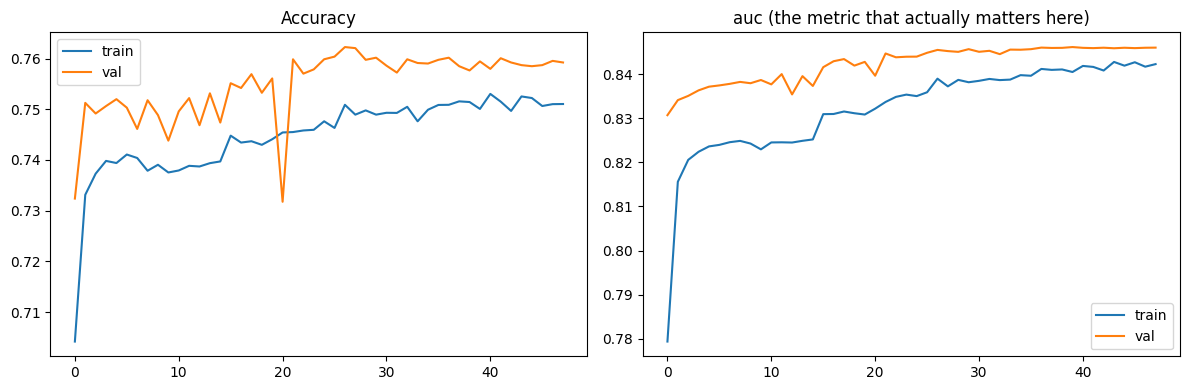

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['auc'], label='train')
axes[1].plot(history.history['val_auc'], label='val')
axes[1].set_title('auc (the metric that actually matters here)'); axes[1].legend()
plt.tight_layout()
plt.show()

In [113]:
# Training accuracy
y_pred_train = np.where(model.predict(X_train_prepared) > 0.5, 1, 0)
train_acc = accuracy_score(y_train, y_pred_train)

# Validation accuracy
y_pred_val = np.where(model.predict(X_val_prepared) > 0.5, 1, 0)
val_acc = accuracy_score(y_val, y_pred_val)

# Test accuracy
y_pred_test = np.where(model.predict(X_test_prepared) > 0.5, 1, 0)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")

1192/1192 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Train Accuracy      : 0.7572
Validation Accuracy : 0.7594
Test Accuracy       : 0.7497


In [117]:
# # Training roc_auc_score
# y_pred_train = np.where(model.predict(X_train_prepared) > 0.5, 1, 0)
# train_roc_auc_score = roc_auc_score(y_train, y_pred_train)

# # Validation roc_auc_score
# y_pred_val = np.where(model.predict(X_val_prepared) > 0.5, 1, 0)
# val_roc_auc_score = roc_auc_score(y_val, y_pred_val)

# # Test roc_auc_score
# y_pred_test = np.where(model.predict(X_test_prepared) > 0.5, 1, 0)
# test_roc_auc_score = roc_auc_score(y_test, y_pred_test)

# print(f"Train roc_auc_score      : {train_roc_auc_score:.4f}")
# print(f"Validation roc_auc_score : {val_roc_auc_score:.4f}")
# print(f"Test roc_auc_score       : {test_roc_auc_score:.4f}")

In [118]:
# Probabilities
y_train_prob = model.predict(X_train_prepared).ravel()
y_val_prob = model.predict(X_val_prepared).ravel()
y_test_prob = model.predict(X_test_prepared).ravel()

print("Train AUC      :", roc_auc_score(y_train, y_train_prob))
print("Validation AUC :", roc_auc_score(y_val, y_val_prob))
print("Test AUC       :", roc_auc_score(y_test, y_test_prob))

1192/1192 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Train AUC      : 0.8499228807118782
Validation AUC : 0.8460987462095002
Test AUC       : 0.8443559458291625


In [114]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76      6252
           1       0.74      0.74      0.74      5668

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



In [115]:
import pickle

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

model.save('model.keras')
print("Saved preprocessor.pkl and model.keras")

Saved preprocessor.pkl and model.keras
